# Preprocess QC — stage-by-stage retention

Tracks every sample through the pipeline and cross-validates between adjacent stages so silent data loss can't hide.

Stages:
1. **ENA `read_count`** — what the manifest says got deposited
2. **Trimmomatic input** — `Input Read Pairs:` / `Input Reads:` from the .err log
3. **Trimmomatic output** — `Both Surviving:` (PE) or `Surviving:` (SE)
4. **Clumpify input** — `Reads In:` (PE: this counts each end → divide by 2 to compare to pairs)
5. **Clumpify output** — `Reads Out:` post-dedup
6. **QC counted** — `n_r1 + n_r2` from zcat | wc -l on the on-disk fq.gz

Cross-checks (`pct_*` columns):
- `pct_ena_to_trim_in` — ENA→Trim input. ~100% means download wasn't truncated.
- `pct_clump_link` — Trim output → Clumpify input. ~100% means Trimmomatic→Clumpify handoff is intact.
- `pct_qc_link` — Clumpify output → on-disk-counted. ~100% means the file wasn't truncated.

Anything outside [95, 105]% on those three is flagged.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path('../output')
df = pd.read_csv(OUT/'stage_aggregate.tsv', sep='\t')
df['ecotype'] = df['ecotype'].astype(str)
print(f'{len(df)} samples (main={(df.panel=="main").sum()}, loo={(df.panel=="loo").sum()})')
df.head(3)

/tmp/ipykernel_65980/308735278.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


226 samples (main=151, loo=75)


,panel,ecotype,layout,trim_in,trim_both_surv,trim_fwd_only,trim_rev_only,trim_surv,trim_dropped,trim_drop_pct,...,pct_trim_surv,pct_clump_link,pct_clump_keep,pct_qc_link,flag_ena_link,flag_low_trim,flag_high_dup,flag_clump_link,flag_qc_link,flag_low_cov
0,main,265,PE,27556948,19661703.0,2215784.0,2228450.0,NaN,3451011,12.52,...,71.349349,100.0,96.329026,100.0,False,False,False,False,False,False
1,main,5151,PE,13000973,12045357.0,162614.0,491493.0,NaN,301509,2.32,...,92.649658,100.0,90.758074,100.0,False,False,False,False,False,False
2,main,5165,PE,13309856,12441049.0,199971.0,382873.0,NaN,285963,2.15,...,93.472454,100.0,93.364080,100.0,False,False,False,False,False,False


## 1. Cross-check pass rates

If preprocess is silently broken anywhere, one of these will show <100%.

In [2]:
checks = pd.DataFrame({
    'check': ['ENA → Trim-In (no truncated DL)',
              'Trim-Out → Clump-In (handoff)',
              'Clump-Out → on-disk QC count (file integrity)'],
    'col':   ['pct_ena_to_trim_in', 'pct_clump_link', 'pct_qc_link'],
    'flag':  ['flag_ena_link', 'flag_clump_link', 'flag_qc_link']
})
rows = []
for _, r in checks.iterrows():
    s = df[r.col].dropna()
    rows.append({
        'check': r.check,
        'n_with_data': len(s),
        'within_95-105': (s.between(95, 105)).sum(),
        'flagged': df[r.flag].fillna(False).sum(),
        'median': s.median(),
        'min': s.min(),
        'max': s.max(),
    })
pd.DataFrame(rows).round(2)

,check,n_with_data,within_95-105,flagged,median,min,max
0,ENA → Trim-In (no truncated DL),224,224,0,100.0,100.0,100.0
1,Trim-Out → Clump-In (handoff),226,226,0,100.0,100.0,100.0
2,Clump-Out → on-disk QC count (file integrity),204,204,0,100.0,100.0,100.0


## 2. Trimmomatic survival distribution

How aggressively did trim cull each library? Tail of distribution = candidates for retrim with looser params.

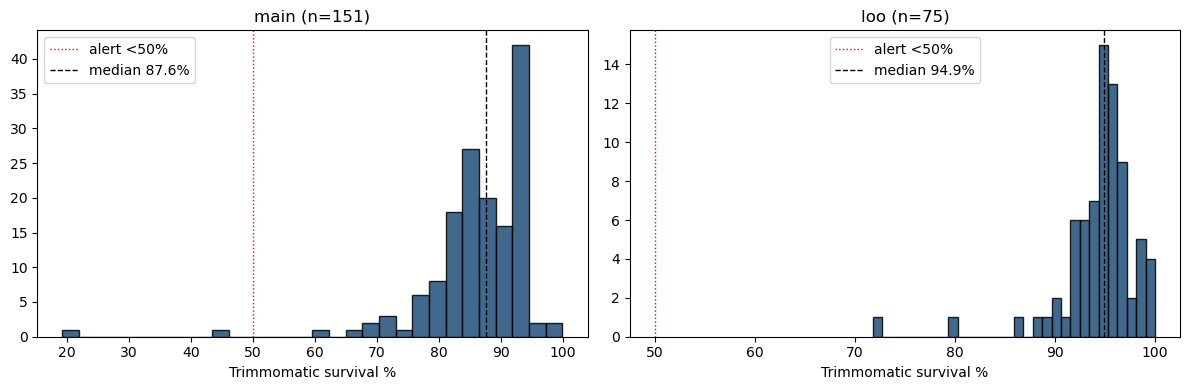

Tail of trim survival (lowest 10):
panel ecotype layout  trim_in   trim_out  pct_trim_surv  dup_pct  cov_est
 main    9977     PE 10270404  1974979.0      19.229808    0.023     1.25
 main    7521     PE 43991664 19280712.0      43.828103    2.195    28.61
 main    7282     PE 19656157 11796130.0      60.012392    0.272    17.37
 main    9944     SE 50714056 33283540.0      65.629813   13.924    12.77
 main    9941     SE 25955116 17737927.0      68.340773    9.851     5.35
 main    9985     SE 25575300 17482653.0      68.357568   11.674     4.92
 main    8376     PE 21955611 15582989.0      70.974973    2.685    24.08
 main     265     PE 27556948 19661703.0      71.349349    3.671    28.51
  loo    6911     PE 36851486 26455749.0      71.790182    3.804    40.16
 main   10014     SE 54599208 39836845.0      72.962313    8.881    12.00


In [3]:
df['pct_trim_surv'] = df.trim_out / df.trim_in * 100
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, panel in zip(axes, ['main','loo']):
    sub = df[df.panel == panel]
    ax.hist(sub.pct_trim_surv, bins=30, color='#1f4e79', edgecolor='k', alpha=0.85)
    ax.axvline(50, color='r', ls=':', lw=1, label='alert <50%')
    ax.axvline(sub.pct_trim_surv.median(), color='k', ls='--', lw=1, label=f'median {sub.pct_trim_surv.median():.1f}%')
    ax.set_xlabel('Trimmomatic survival %')
    ax.set_title(f'{panel} (n={len(sub)})')
    ax.legend()
plt.tight_layout(); plt.show()

print('Tail of trim survival (lowest 10):')
print(df.nsmallest(10, 'pct_trim_surv')[['panel','ecotype','layout','trim_in','trim_out','pct_trim_surv','dup_pct','cov_est']].to_string(index=False))

## 3. Clumpify dedup distribution

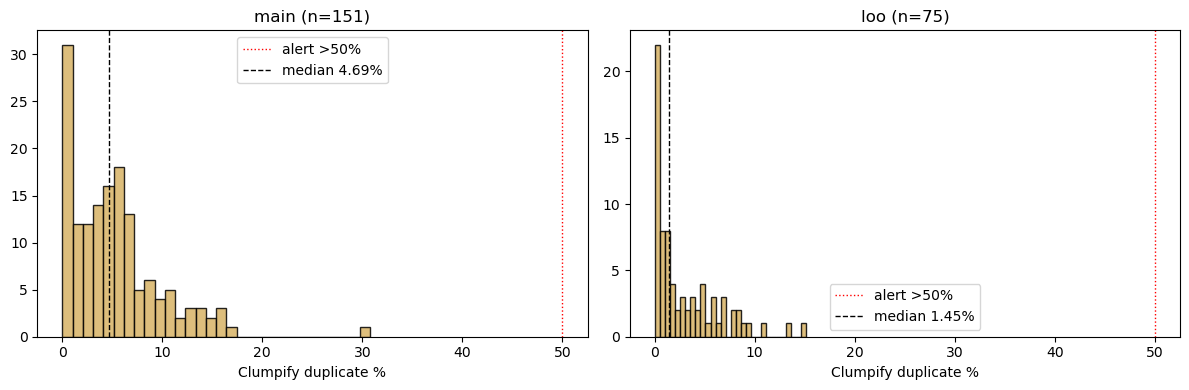

Top 10 by dup rate:
panel ecotype layout  clump_in  clump_out  dup_count  dup_pct  cov_est
 main    6216     PE 136257636   94376352   41881284   30.737    57.74
 main    6243     PE  37252068   31013178    6238890   16.748    18.67
 main    6074     PE  37070682   31040680    6030002   16.266    18.82
 main    6040     PE  34838332   29375894    5462438   15.679    17.93
 main    6013     PE  56350178   47540700    8809478   15.633    29.33
 main    6108     PE  53487294   45329586    8157708   15.252    27.94
  loo    9947     SE  31932659   27090380    4842279   15.164      NaN
 main    6073     PE  73504686   62403252   11101434   15.103    38.15
 main    6177     PE  60249828   51697440    8552388   14.195    31.65
 main    9944     SE  33283540   28649273    4634267   13.924    12.77


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, panel in zip(axes, ['main','loo']):
    sub = df[df.panel == panel]
    ax.hist(sub.dup_pct, bins=30, color='#d8b365', edgecolor='k', alpha=0.85)
    ax.axvline(50, color='r', ls=':', lw=1, label='alert >50%')
    ax.axvline(sub.dup_pct.median(), color='k', ls='--', lw=1, label=f'median {sub.dup_pct.median():.2f}%')
    ax.set_xlabel('Clumpify duplicate %')
    ax.set_title(f'{panel} (n={len(sub)})')
    ax.legend()
plt.tight_layout(); plt.show()

print('Top 10 by dup rate:')
print(df.nlargest(10, 'dup_pct')[['panel','ecotype','layout','clump_in','clump_out','dup_count','dup_pct','cov_est']].to_string(index=False))

## 4. Stage-by-stage retention per ecotype (stacked bar, sample-by-sample)

Each row of the stacked bar shows: % of ENA reads dropped at trim, % dropped at dedup, % surviving (= what's on disk). Sorted by surviving fraction. Far-right (high survival) is healthy; far-left (low) is over-trimmed.

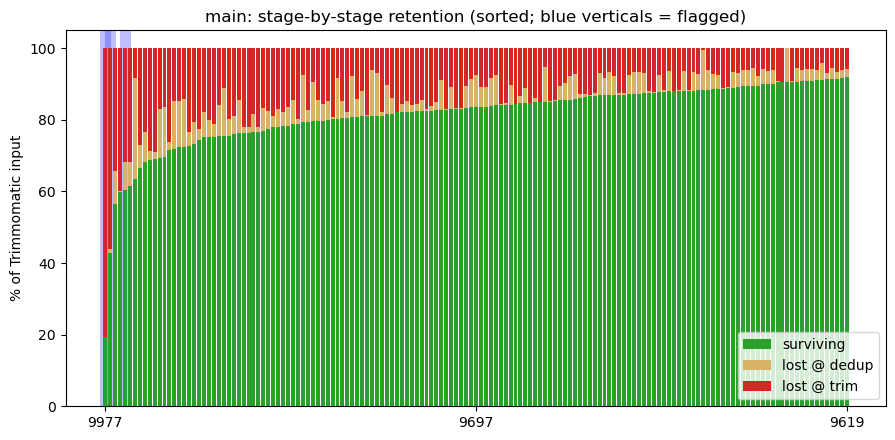

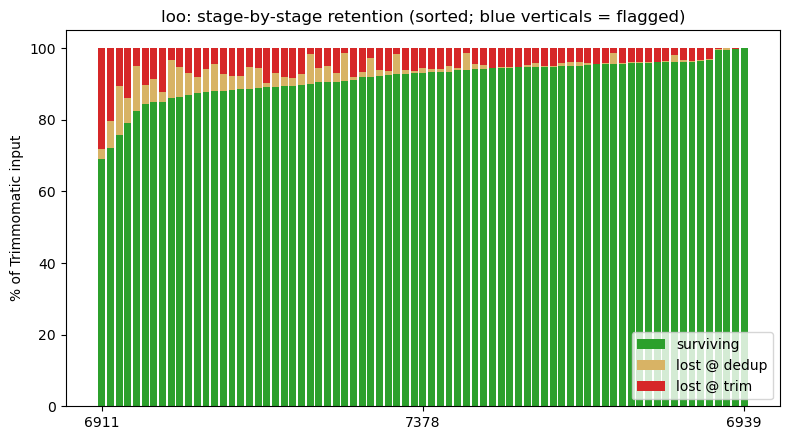

In [5]:
for panel in ['main','loo']:
    sub = df[df.panel == panel].copy()
    sub['pct_trim_drop'] = (sub.trim_in - sub.trim_out) / sub.trim_in * 100
    sub['pct_dedup_drop'] = (sub.clump_in_pairs - sub.clump_out_pairs) / sub.trim_in * 100
    sub['pct_surviving']  = sub.clump_out_pairs / sub.trim_in * 100
    sub = sub.sort_values('pct_surviving').reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(max(8, len(sub)*0.06), 4.5))
    x = np.arange(len(sub))
    ax.bar(x, sub.pct_surviving,    color='#2ca02c', label='surviving')
    ax.bar(x, sub.pct_dedup_drop,   bottom=sub.pct_surviving, color='#d8b365', label='lost @ dedup')
    ax.bar(x, sub.pct_trim_drop,    bottom=sub.pct_surviving + sub.pct_dedup_drop, color='#d62728', label='lost @ trim')
    # Highlight flagged
    flagged_idx = sub[sub.flag_low_trim | sub.flag_low_cov].index
    for i in flagged_idx:
        ax.axvline(i, color='blue', alpha=0.25, lw=8, zorder=0)
    ax.set_xticks([0, len(sub)//2, len(sub)-1])
    ax.set_xticklabels([sub.ecotype.iloc[i] for i in [0, len(sub)//2, len(sub)-1]])
    ax.set_ylabel('% of Trimmomatic input')
    ax.set_title(f'{panel}: stage-by-stage retention (sorted; blue verticals = flagged)')
    ax.legend(loc='lower right')
    ax.set_ylim(0, 105)
    plt.tight_layout(); plt.show()

## 5. Coverage vs trim survival (where do losses translate to coverage hits?)

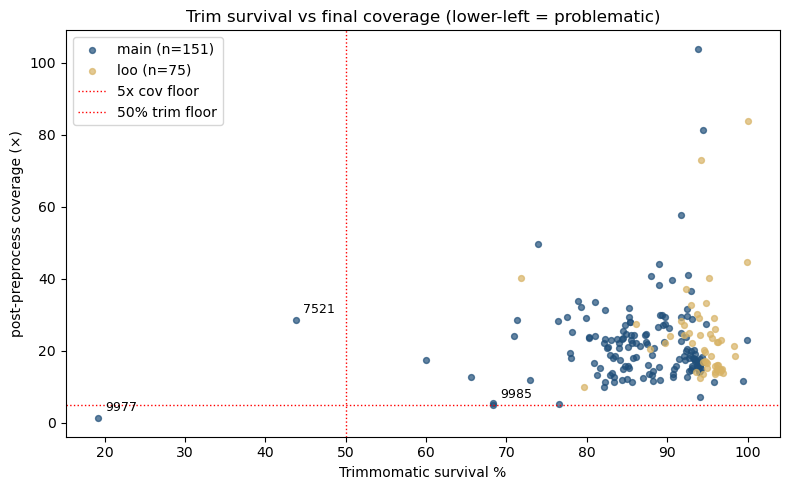

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for panel, color in [('main', '#1f4e79'), ('loo', '#d8b365')]:
    sub = df[df.panel == panel]
    ax.scatter(sub.pct_trim_surv, sub.cov_est, s=18, alpha=0.7, label=f'{panel} (n={len(sub)})', color=color)
ax.axhline(5, color='r', ls=':', lw=1, label='5x cov floor')
ax.axvline(50, color='r', ls=':', lw=1, label='50% trim floor')
# Annotate flagged samples
flagged = df[df.flag_low_trim | df.flag_low_cov]
for _, r in flagged.iterrows():
    ax.annotate(r.ecotype, (r.pct_trim_surv, r.cov_est), fontsize=9,
                xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('Trimmomatic survival %')
ax.set_ylabel('post-preprocess coverage (×)')
ax.set_title('Trim survival vs final coverage (lower-left = problematic)')
ax.legend()
plt.tight_layout(); plt.show()

## 6. Anomaly summary

In [7]:
flag_cols = ['flag_ena_link', 'flag_low_trim', 'flag_high_dup',
             'flag_clump_link', 'flag_qc_link', 'flag_low_cov']
summary = df[flag_cols].fillna(False).sum().to_frame('count')
summary['description'] = ['ENA reads ≠ Trim input (truncated DL)',
                          'Trim survival < 50% (over-trim or bad data)',
                          'Dedup > 50% (PCR-heavy library)',
                          'Trim → Clumpify mismatch',
                          'Clumpify → on-disk count mismatch (truncated file)',
                          'Final coverage < 5×']
print(summary)
print()
any_flag = df[flag_cols].fillna(False).any(axis=1)
if any_flag.sum() == 0:
    print('NO ANOMALIES — everything passes cross-checks.')
else:
    print(f'\n{any_flag.sum()} samples with one or more flag set:')
    cols = ['panel','ecotype','layout','read_count','trim_in','trim_out',
            'clump_out_pairs','qc_reads_pairs','cov_est',
            'pct_trim_surv','dup_pct'] + flag_cols
    print(df[any_flag][cols].to_string(index=False))

                 count                                        description
flag_ena_link        0              ENA reads ≠ Trim input (truncated DL)
flag_low_trim        2        Trim survival < 50% (over-trim or bad data)
flag_high_dup        0                    Dedup > 50% (PCR-heavy library)
flag_clump_link      0                           Trim → Clumpify mismatch
flag_qc_link         0  Clumpify → on-disk count mismatch (truncated f...
flag_low_cov         2                                Final coverage < 5×


3 samples with one or more flag set:
panel ecotype layout  read_count  trim_in   trim_out  clump_out_pairs  qc_reads_pairs  cov_est  pct_trim_surv  dup_pct  flag_ena_link  flag_low_trim  flag_high_dup  flag_clump_link  flag_qc_link  flag_low_cov
 main    7521     PE  43991664.0 43991664 19280712.0       18857470.0      18857470.0    28.61      43.828103    2.195          False           True          False            False         False         False
 main    9977     PE  102

## 7. Per-sample drill-down (interactive)

In [8]:
def stage_table(eco):
    r = df[df.ecotype == str(eco)].iloc[0]
    return pd.DataFrame({
        'stage': ['ENA reads', 'Trim input', 'Trim output', 'Clump input (pairs)',
                  'Clump output (pairs)', 'QC reads (pairs)'],
        'count': [r.read_count, r.trim_in, r.trim_out, r.clump_in_pairs,
                  r.clump_out_pairs, r.qc_reads_pairs]
    })

for eco in [9977, 9985, 7521, 7287]:
    print(f'\n=== {eco} ===')
    print(stage_table(eco).to_string(index=False))


=== 9977 ===
               stage      count
           ENA reads 10270404.0
          Trim input 10270404.0
         Trim output  1974979.0
 Clump input (pairs)  1974979.0
Clump output (pairs)  1974523.0
    QC reads (pairs)  1974523.0

=== 9985 ===
               stage      count
           ENA reads 25575300.0
          Trim input 25575300.0
         Trim output 17482653.0
 Clump input (pairs) 17482653.0
Clump output (pairs) 15441738.0
    QC reads (pairs) 15441738.0

=== 7521 ===
               stage      count
           ENA reads 43991664.0
          Trim input 43991664.0
         Trim output 19280712.0
 Clump input (pairs) 19280712.0
Clump output (pairs) 18857470.0
    QC reads (pairs) 18857470.0

=== 7287 ===
               stage      count
           ENA reads 55026774.0
          Trim input 55026774.0
         Trim output 51964673.0
 Clump input (pairs) 51964673.0
Clump output (pairs) 50313910.0
    QC reads (pairs) 50313910.0
